In [1]:
import json

In [2]:
with open('answers.txt', 'r') as file:
    answers = file.readlines()
    answers = [answer.strip() for answer in answers]
    answers = [[ans1, ans2] for ans1, ans2 in (answer.split(',') for answer in answers)]
print(answers)

[['Back', 'Right'], ['Back', 'Right'], ['Front', 'Right'], ['Back', 'Right'], ['Back', 'Right'], ['Back', 'Right'], ['Front', 'Left'], ['Back', 'Right'], ['Front', 'Left'], ['Back', 'Right'], ['Back', 'Right'], ['Back', 'Right'], ['Back', 'Right'], ['Front', 'Left'], ['Back', 'Right'], ['Back', 'Right'], ['Front', 'Left'], ['Front', 'Left'], ['Back', 'Left'], ['Front', 'Left'], ['Back', 'Left'], ['Back', 'Right'], ['Front', 'Left'], ['Back', 'Right'], ['Back', 'Left'], ['Back', 'Left'], ['Front', 'Left'], ['Back', 'Left'], ['Front', 'Right'], ['Back', 'Left'], ['Front', 'Right'], ['Front', 'Right'], ['Back', 'Left'], ['Back', 'Right'], ['Front', 'Left'], ['Back', 'Right'], ['Front', 'Left'], ['Back', 'Right'], ['Back', 'Right'], ['Front', 'Left'], ['Back', 'Right']]


In [3]:
left_right_answers = [ans[1].lower() for ans in answers]
print(left_right_answers)

['right', 'right', 'right', 'right', 'right', 'right', 'left', 'right', 'left', 'right', 'right', 'right', 'right', 'left', 'right', 'right', 'left', 'left', 'left', 'left', 'left', 'right', 'left', 'right', 'left', 'left', 'left', 'left', 'right', 'left', 'right', 'right', 'left', 'right', 'left', 'right', 'left', 'right', 'right', 'left', 'right']


In [4]:
# get alignment variable
with open('alignment.txt', 'r') as file:
    alignment = file.readlines()
    alignment = [align.strip() for align in alignment]
print(alignment[:10])

['1', '1', '1', '1', '1', '2', '1', '1', '1', '1']


### Base results

In [5]:
with open('answers/vpt_ib_answers_base.jsonl', 'r') as f:
    base_answers = [json.loads(line) for line in f]
base_answers = [answer['text'] for answer in base_answers]
print(base_answers)

["From the person's perspective, the bat is on the left side.", "From the person's perspective, the bat is on the right side.", "From the person's perspective, the trophy is on their left side.", "From the person's perspective, the trophy is on the right side.", "From the person's perspective, the trophy is on the left side.", "From the person's perspective, the chair is on the right side.", "From the person's perspective, the potted plant is on their right side.", "From the person's perspective, the potted plant is on their left side.", "From the person's perspective, the tv is on their right side.", "From the person's perspective, the tv is on their right side.", "From the person's perspective, the tv is on their right side.", "From the person's perspective, the tv is on their right side.", "From the person's perspective, the tv is on their left side.", "From the person's perspective, the tv is on their right side.", "From the person's perspective, the tv is on their right side.", "F

In [6]:
base_answers_clean = []

for ans in base_answers:
    if 'left' in ans.lower():
        base_answers_clean.append('left')
    elif 'right' in ans.lower():
        base_answers_clean.append('right')
    else:
        base_answers_clean.append('unknown')
print(base_answers_clean)

['left', 'right', 'left', 'right', 'left', 'right', 'right', 'left', 'right', 'right', 'right', 'right', 'left', 'right', 'right', 'left', 'left', 'left', 'left', 'right', 'right', 'left', 'left', 'right', 'right', 'left', 'right', 'right', 'left', 'left', 'right', 'left', 'right', 'right', 'left', 'right', 'left', 'right', 'left', 'left', 'right']


In [35]:
base_correct = [base == lr for base, lr in zip(base_answers_clean, left_right_answers)]
base_acc = sum(base_correct) / len(base_correct)
print(f"Base accuracy: {base_acc:.4f}")

Base accuracy: 0.5366


1.0 0.2727272727272727 0.625


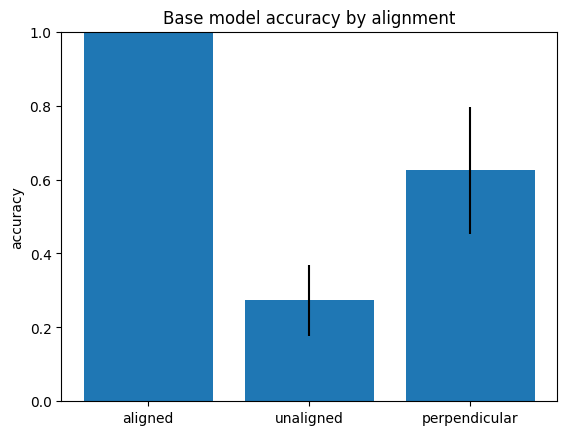

In [36]:
# plot base_correct as a function of alignment
import matplotlib.pyplot as plt
import numpy as np

# alignment has 3 categories: 1 is unaligned, 0 is aligned, 2 is perpendicular
# lets make a bar plot of accuracy for each category with error bars
alignment = np.array(alignment)
base_correct = np.array(base_correct)
aligned_acc = np.mean(base_correct[alignment == '0'])
base_unaligned_acc = np.mean(base_correct[alignment == '1'])
perpendicular_acc = np.mean(base_correct[alignment == '2'])
print(aligned_acc, base_unaligned_acc, perpendicular_acc)
# mean of just alig 0 and 1
base_acc = np.mean(base_correct[alignment != '2'])
aligned_sem = np.std(base_correct[alignment == '0']) / np.sqrt(len(base_correct[alignment == '0']))
unaligned_sem = np.std(base_correct[alignment == '1']) / np.sqrt(len(base_correct[alignment == '1']))
perpendicular_sem = np.std(base_correct[alignment == '2']) / np.sqrt(len(base_correct[alignment == '2']))
plt.bar(['aligned', 'unaligned', 'perpendicular'], [aligned_acc, base_unaligned_acc, perpendicular_acc], yerr=[aligned_sem, unaligned_sem, perpendicular_sem])
plt.ylim(0, 1)
plt.ylabel('accuracy')
plt.title('Base model accuracy by alignment')
plt.show()

In [9]:
# let's see what unaligned were correct
# find indices of unaligned that were correct
unaligned_correct_indices = np.where((alignment == '1') & (base_correct == True))
print(unaligned_correct_indices)

(array([ 1,  3,  9, 36, 39, 40], dtype=int64),)


<Figure size 1000x600 with 0 Axes>

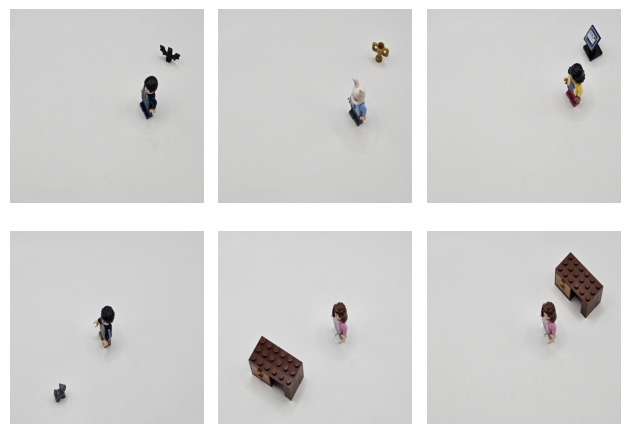

In [10]:
# plot the images at these indices (indices + .png from "images" directory)
import os
import matplotlib.image as mpimg

# make a 2x3 grid of images
plt.figure(figsize=(10, 6))
axs = plt.subplots(2, 3)[1]
for i, idx in enumerate(unaligned_correct_indices[0]):
    img_path = os.path.join('images', f'{idx}.png')
    img = mpimg.imread(img_path)
    axs[i // 3, i % 3].imshow(img)
    axs[i // 3, i % 3].axis('off')
plt.tight_layout()
plt.show()

*** all more "birds-eye view" photos -> model may be guessing correctly

### Text results

In [11]:
with open('answers/vpt_ib_answers_vit_text.jsonl', 'r') as f:
    vit_text_answers = [json.loads(line) for line in f]
vit_text_answers = [answer['text'] for answer in vit_text_answers]
print(vit_text_answers)

['right', 'left', 'right', 'left', 'right', 'right', 'left', 'left', 'right', 'right', 'right', 'right', 'right', 'left', 'right', 'right', 'left', 'left', 'left', 'right', 'left', 'left', 'left', 'right', 'right', 'left', 'right', 'left', 'left', 'left', 'right', 'right', 'left', 'right', 'left', 'right', 'left', 'right', 'left', 'right', 'right']


In [45]:
vit_text_correct = [vit == lr for vit, lr in zip(vit_text_answers, left_right_answers)]
text_acc = sum(vit_text_correct)/len(vit_text_correct)
print(f"Text accuracy: {text_acc:.4f}")

Text accuracy: 0.7317


In [13]:
vit_text_aligned_acc = np.mean(np.array(vit_text_correct)[alignment == '0'])
vit_text_unaligned_acc = np.mean(np.array(vit_text_correct)[alignment == '1'])
vit_text_perpendicular_acc = np.mean(np.array(vit_text_correct)[alignment == '2'])
print(vit_text_aligned_acc, vit_text_unaligned_acc, vit_text_perpendicular_acc)

1.0 0.6363636363636364 0.625


In [46]:
text_acc = np.mean(np.array(vit_text_correct)[alignment != '2'])
print(f"Text accuracy (excluding perpendicular): {text_acc:.4f}")


Text accuracy (excluding perpendicular): 0.7576


#### cot

In [47]:
with open('answers/vpt_ib_answers_vit_text_cot.jsonl', 'r') as f:
    vit_text_cot_answers = [json.loads(line) for line in f]
vit_text_cot_answers = [answer['text'].split('is to the ')[1].split(' from the perspective of the')[0] for answer in vit_text_cot_answers]
print(vit_text_cot_answers)

['right', 'left', 'right', 'left', 'right', 'left', 'right', 'right', 'right', 'left', 'right', 'right', 'right', 'left', 'right', 'right', 'right', 'left', 'right', 'left', 'left', 'left', 'right', 'right', 'left', 'left', 'right', 'left', 'left', 'left', 'right', 'right', 'left', 'right', 'left', 'right', 'left', 'right', 'right', 'right', 'left']


In [48]:
vit_text_cot_correct = [vit == lr for vit, lr in zip(vit_text_cot_answers, left_right_answers)]
text_cot_acc = sum(vit_text_cot_correct)/len(vit_text_cot_correct)
print(f"Text CoT accuracy: {text_cot_acc:.4f}")

Text CoT accuracy: 0.6585


In [49]:
vit_text_cot_aligned_acc = np.mean(np.array(vit_text_cot_correct)[alignment == '0'])
vit_text_cot_unaligned_acc = np.mean(np.array(vit_text_cot_correct)[alignment == '1'])
vit_text_cot_perpendicular_acc = np.mean(np.array(vit_text_cot_correct)[alignment == '2'])
print(vit_text_cot_aligned_acc, vit_text_cot_unaligned_acc, vit_text_cot_perpendicular_acc)

0.8181818181818182 0.6818181818181818 0.375


In [50]:
text_cot_acc = np.mean(np.array(vit_text_cot_correct)[alignment != '2'])
print(f"Text CoT accuracy (excluding perpendicular): {text_cot_acc:.4f}")

Text CoT accuracy (excluding perpendicular): 0.7273


In [51]:
text_avg_acc = (text_acc + text_cot_acc) / 2
text_avg_unaligned_acc = (vit_text_unaligned_acc + vit_text_cot_unaligned_acc) / 2
text_avg_acc - base_acc, text_avg_unaligned_acc - base_unaligned_acc

(0.2272727272727273, 0.38636363636363635)

### COCO results

In [19]:
with open('answers/vpt_ib_answers_coco.jsonl', 'r') as f:
    coco_answers = [json.loads(line) for line in f]
coco_answers = [answer['text'] for answer in coco_answers]
print(coco_answers)

['left', 'right', 'left', 'right', 'right', 'left', 'left', 'left', 'right', 'right', 'right', 'right', 'right', 'left', 'right', 'right', 'left', 'left', 'left', 'left', 'left', 'left', 'left', 'right', 'left', 'left', 'right', 'left', 'left', 'left', 'right', 'right', 'left', 'right', 'left', 'right', 'right', 'right', 'left', 'left', 'right']


In [37]:
coco_correct = [coco == lr for coco, lr in zip(coco_answers, left_right_answers)]
coco_acc = sum(coco_correct) / len(coco_correct)
print(f"Coco accuracy: {coco_acc:.4f}")

Coco accuracy: 0.7561


In [21]:
coco_aligned_acc = np.mean(np.array(coco_correct)[alignment == '0'])
coco_unaligned_acc = np.mean(np.array(coco_correct)[alignment == '1'])
coco_perpendicular_acc = np.mean(np.array(coco_correct)[alignment == '2'])
print(coco_aligned_acc, coco_unaligned_acc, coco_perpendicular_acc)

1.0 0.7272727272727273 0.5


In [38]:
coco_acc = np.mean(np.array(coco_correct)[alignment != '2'])
print(f"Coco accuracy (excluding perpendicular): {coco_acc:.4f}")

Coco accuracy (excluding perpendicular): 0.8182


#### cot

In [39]:
with open('answers/vpt_ib_answers_coco_cot.jsonl', 'r') as f:
    coco_cot_answers = [json.loads(line) for line in f]
coco_cot_answers = [answer['text'].split('is to the ')[1].split(' from the perspective of the')[0] for answer in coco_cot_answers]
print(coco_cot_answers)

['right', 'left', 'right', 'right', 'left', 'left', 'right', 'right', 'left', 'right', 'right', 'right', 'right', 'left', 'right', 'right', 'left', 'left', 'left', 'left', 'left', 'left', 'left', 'right', 'left', 'left', 'right', 'left', 'left', 'left', 'right', 'right', 'left', 'right', 'left', 'right', 'left', 'right', 'right', 'right', 'right']


In [40]:
coco_cot_correct = [coco == lr for coco, lr in zip(coco_cot_answers, left_right_answers)]
coco_cot_acc = sum(coco_cot_correct) / len(coco_cot_correct)
print(f"Coco CoT accuracy: {coco_cot_acc:.4f}")

Coco CoT accuracy: 0.8049


In [25]:
coco_cot_aligned_acc = np.mean(np.array(coco_cot_correct)[alignment == '0'])
coco_cot_unaligned_acc = np.mean(np.array(coco_cot_correct)[alignment == '1'])
coco_cot_perpendicular_acc = np.mean(np.array(coco_cot_correct)[alignment == '2'])
print(coco_cot_aligned_acc, coco_cot_unaligned_acc, coco_cot_perpendicular_acc)

1.0 0.8181818181818182 0.5


In [41]:
coco_cot_acc = np.mean(np.array(coco_cot_correct)[alignment != '2'])
print(f"Coco CoT accuracy (excluding perpendicular): {coco_cot_acc:.4f}")

Coco CoT accuracy (excluding perpendicular): 0.8788


In [42]:
coco_avg_acc = (coco_acc + coco_cot_acc) / 2
coco_avg_unaligned_acc = (coco_unaligned_acc + coco_cot_unaligned_acc) / 2
coco_avg_acc - base_acc, coco_avg_unaligned_acc - base_unaligned_acc

(0.33333333333333337, 0.5)

### ViT results

In [27]:
with open('answers/vpt_ib_answers_vit.jsonl', 'r') as f:
    vit_answers = [json.loads(line) for line in f]
vit_answers = [answer['text'] for answer in vit_answers]
print(vit_answers)

['left', 'left', 'right', 'left', 'left', 'left', 'right', 'left', 'left', 'right', 'right', 'right', 'right', 'left', 'right', 'right', 'left', 'left', 'right', 'left', 'left', 'left', 'right', 'right', 'left', 'right', 'left', 'left', 'right', 'left', 'left', 'left', 'left', 'right', 'left', 'right', 'left', 'right', 'right', 'left', 'left']


In [28]:
vit_correct = [vit == lr for vit, lr in zip(vit_answers, left_right_answers)]
print(sum(vit_correct) / len(vit_correct))

0.6585365853658537


In [29]:
vit_aligned_acc = np.mean(np.array(vit_correct)[alignment == '0'])
vit_unaligned_acc = np.mean(np.array(vit_correct)[alignment == '1'])
vit_perpendicular_acc = np.mean(np.array(vit_correct)[alignment == '2'])
print(vit_aligned_acc, vit_unaligned_acc, vit_perpendicular_acc)

0.8181818181818182 0.6363636363636364 0.5


In [30]:
print(np.mean(np.array(vit_correct)[alignment != '2']))

0.696969696969697


#### Cot

In [31]:
with open('answers/vpt_ib_answers_vit_cot.jsonl', 'r') as f:
    vit_cot_answers = [json.loads(line) for line in f]
vit_cot_answers = [answer['text'].split('is to the ')[1].split(' from the perspective of the')[0] for answer in vit_cot_answers]
print(vit_cot_answers)

['right', 'right', 'left', 'left', 'left', 'left', 'left', 'left', 'right', 'right', 'right', 'left', 'right', 'left', 'right', 'right', 'left', 'left', 'right', 'left', 'left', 'left', 'left', 'right', 'left', 'left', 'right', 'left', 'left', 'right', 'right', 'right', 'left', 'right', 'left', 'right', 'right', 'right', 'left', 'left', 'right']


In [32]:
vit_cot_correct = [vit == lr for vit, lr in zip(vit_cot_answers, left_right_answers)]
print(sum(vit_cot_correct) / len(vit_cot_correct))

0.6585365853658537


In [33]:
vit_cot_aligned_acc = np.mean(np.array(vit_cot_correct)[alignment == '0'])
vit_cot_unaligned_acc = np.mean(np.array(vit_cot_correct)[alignment == '1'])
vit_cot_perpendicular_acc = np.mean(np.array(vit_cot_correct)[alignment == '2'])
print(vit_cot_aligned_acc, vit_cot_unaligned_acc, vit_cot_perpendicular_acc)

0.8181818181818182 0.6818181818181818 0.375


In [34]:
print(np.mean(np.array(vit_cot_correct)[alignment != '2']))

0.7272727272727273
